# Exercise 3 — Online Customer Purchase Prediction

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

In [11]:
DATA_URL = "https://raw.githubusercontent.com/santoshc1/PowerBI-AI-samples/master/Tutorial_AutomatedML/online_shoppers_intention.csv"
df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (12359, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,1,0.000000,2,211.25,144,4627.489571,0.001361,0.020664,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,False,NaN
1,7,150.357143,1,9.00,221,11431.001240,0.011149,0.021904,1.582473,0.0,Nov,2,5,1,2,Returning_Visitor,True,NaN
2,3,16.000000,3,86.00,15,2773.500000,0.000000,0.030000,78.811725,0.0,Dec,2,2,1,2,Returning_Visitor,False,NaN
3,0,0.000000,0,0.00,7,705.833333,0.028571,0.085714,0.000000,0.0,Dec,5,11,4,1,Returning_Visitor,True,NaN
4,0,0.000000,0,0.00,7,212.500000,0.000000,0.033333,0.000000,0.0,Nov,3,2,1,11,Returning_Visitor,True,NaN


In [12]:
display(df.isnull().sum())
display(df.describe(include="all").T)

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12359.0,NaN,NaN,NaN,2.314669,3.320541,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12359.0,NaN,NaN,NaN,80.864872,176.902495,0.0,0.0,7.5,93.2125,3398.75
Informational,12359.0,NaN,NaN,NaN,0.504005,1.270106,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12359.0,NaN,NaN,NaN,34.546019,140.819745,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12359.0,NaN,NaN,NaN,31.746905,44.494101,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12359.0,NaN,NaN,NaN,1195.526779,1914.759359,0.0,184.175,599.1,1464.313143,63973.52223
BounceRates,12359.0,NaN,NaN,NaN,0.022151,0.04844,0.0,0.0,0.003101,0.016667,0.2
ExitRates,12359.0,NaN,NaN,NaN,0.043041,0.048557,0.0,0.014286,0.025141,0.05,0.2
PageValues,12359.0,NaN,NaN,NaN,5.895999,18.572324,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12359.0,NaN,NaN,NaN,0.061283,0.198706,0.0,0.0,0.0,0.0,1.0


In [13]:
df = df.dropna(subset=["Revenue"])

df["Revenue"] = df["Revenue"].astype(int)

numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

categorical_features = [
    "Month",
    "VisitorType",
    "Weekend"
]

X = df[numeric_features + categorical_features]
y = df["Revenue"]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9864
Testing samples: 2466


In [14]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual Purchase": y_test.values,
    "Predicted Purchase": y_pred,
    "Purchase Probability": y_prob
})

display(results.head(10))

,Actual Purchase,Predicted Purchase,Purchase Probability
0,0,0,0.023080
1,0,0,0.069671
2,1,1,0.992088
3,0,0,0.015262
4,0,0,0.009233
5,0,0,0.071242
6,1,0,0.040253
7,0,0,0.236665
8,0,0,0.129164
9,0,0,0.085743


In [16]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8812
ROC-AUC: 0.8873
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



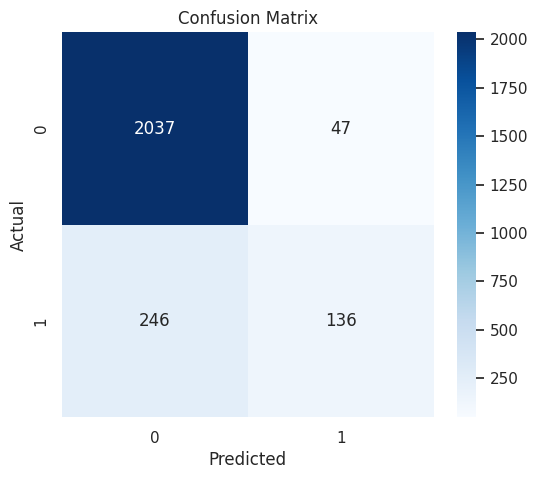

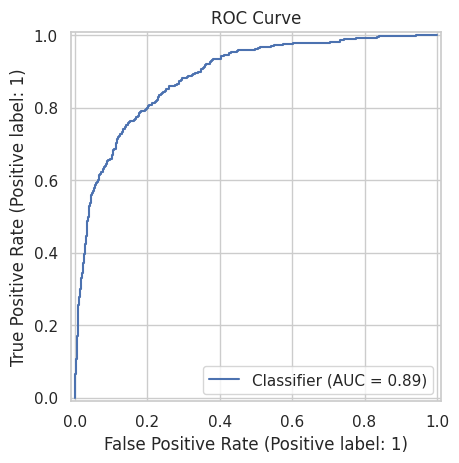

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [18]:
new_customer = pd.DataFrame({
    "Administrative": [2],
    "Administrative_Duration": [50],
    "Informational": [1],
    "Informational_Duration": [20],
    "ProductRelated": [15],
    "ProductRelated_Duration": [600],
    "BounceRates": [0.02],
    "ExitRates": [0.04],
    "PageValues": [20],
    "SpecialDay": [0],
    "OperatingSystems": [2],
    "Browser": [2],
    "Region": [1],
    "TrafficType": [2],
    "Month": ["Nov"],
    "VisitorType": ["Returning_Visitor"],
    "Weekend": [False]
})

new_customer = pd.get_dummies(
    new_customer,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

probability = model.predict_proba(new_customer)[0, 1]
prediction = model.predict(new_customer)[0]

print(f"Purchase probability: {probability:.2%}")
print("Prediction:", "Likely to purchase" if prediction == 1 else "Unlikely to purchase")

Purchase probability: 33.48%
Prediction: Unlikely to purchase
